# Unidad 1: Fundamentos y Análisis de Algoritmos
## Semana 1: Introducción y Repaso Práctico

### Objetivos de Aprendizaje:
1. **Formalizar** la definición de algoritmo y comprender el ciclo de vida de resolución de un problema computacional.
2. **Implementar** y comparar estructuras de datos lineales (Pilas, Colas y Listas Enlazadas) utilizando Programación Orientada a Objetos (POO) y tipado estático en Python.
3. **Medir experimentalmente** la complejidad temporal empírica ($t$ vs $n$) para entender la diferencia práctica entre operaciones de tiempo constante $O(1)$ y tiempo lineal $O(n)$.

### Requisitos Previos:
- Conocimientos sólidos de Programación Orientada a Objetos en Python (Clases, Métodos, Herencia).
- Estructuras de datos básicas (listas, tuplas, diccionarios en Python).


## 1. Contexto Teórico Riguroso

### ¿Qué es un Algoritmo?
Un **algoritmo** es una secuencia finita de instrucciones precisas, bien definidas y no ambiguas, que al ejecutarse resuelven un problema computacional específico en un tiempo finito. Formalmente, un algoritmo toma una entrada (input) que cumple con ciertas precondiciones, realiza una serie de transformaciones discretas y produce una salida (output) que satisface las postcondiciones deseadas.

### El Ciclo de Vida de Resolución de un Problema
Resolver problemas en la industria del software no se limita a escribir código de manera inmediata. Sigue un ciclo estructurado:

```
[Especificación Formal] ➔ [Diseño del Algoritmo] ➔ [Demostración de Corrección] ➔ [Análisis de Complejidad] ➔ [Implementación y Pruebas]
```

1. **Especificación:** Definir claramente qué se quiere resolver, qué entradas se reciben y qué salidas se esperan.
2. **Diseño:** Elegir la estrategia algorítmica (fuerza bruta, divide y vencerás, etc.) y las estructuras de datos adecuadas.
3. **Corrección:** Demostrar formalmente que el algoritmo funciona para todos los casos de entrada válidos (usando inducción matemática o invariantes de bucle).
4. **Análisis de Complejidad:** Estimar la cantidad de recursos (tiempo y memoria) que el algoritmo consumirá en función del tamaño de la entrada ($n$).
5. **Implementación y Pruebas:** Codificar de manera limpia y modular, y verificar con pruebas unitarias y de rendimiento.



## 2. Implementación desde Cero (Python 3 + POO)

En Python, la estructura por defecto `list` es un **arreglo dinámico**. Esto significa que operaciones como eliminar el primer elemento (`list.pop(0)`) requieren desplazar todos los elementos restantes una posición a la izquierda en memoria, lo que toma tiempo lineal $O(n)$.

Para solucionar esto de manera óptima, implementaremos una **Cola (Queue)** basada en una **Lista Enlazada Simple** con dos referencias (`head` y `tail`). Esto permite que tanto `enqueue` como `dequeue` se ejecuten en tiempo constante $O(1)$.

### Comparación de Diseños: Cola Ineficiente (Naive) vs Cola Optimizada


In [1]:
import time
from typing import Any, Optional

# ==========================================
# 1. ENFOQUE NAIVE (Arreglo Dinámico NATIVO)
# ==========================================
class NaiveQueue:
    def __init__(self) -> None:
        self._items: list[Any] = []

    def enqueue(self, item: Any) -> None:
        """O(1) amortizado."""
        self._items.append(item)

    def dequeue(self) -> Any:
        """O(n) debido al desplazamiento en memoria del pop(0)."""
        if self.is_empty():
            raise IndexError("dequeue de una cola vacía")
        return self._items.pop(0)

    def is_empty(self) -> bool:
        return len(self._items) == 0

    def size(self) -> int:
        return len(self._items)


# ==========================================
# 2. ENFOQUE OPTIMIZADO (Lista Enlazada)
# ==========================================
class Node:
    def __init__(self, value: Any) -> None:
        self.value: Any = value
        self.next: Optional[Node] = None

class OptimizedQueue:
    def __init__(self) -> None:
        self._head: Optional[Node] = None
        self._tail: Optional[Node] = None
        self._size: int = 0

    def enqueue(self, item: Any) -> None:
        """O(1) estricto."""
        new_node = Node(item)
        if self._tail is None:
            self._head = new_node
            self._tail = new_node
        else:
            self._tail.next = new_node
            self._tail = new_node
        self._size += 1

    def dequeue(self) -> Any:
        """O(1) estricto."""
        if self.is_empty():
            raise IndexError("dequeue de una cola vacía")
        
        temp = self._head
        assert temp is not None
        value = temp.value
        self._head = temp.next
        
        if self._head is None:
            self._tail = None
            
        self._size -= 1
        return value

    def is_empty(self) -> bool:
        return self._size == 0

    def size(self) -> int:
        return self._size


# ==========================================
# 3. PRUEBA DE RENDIMIENTO (BENCHMARK)
# ==========================================
def benchmark_queue(queue_cls, n_elements: int) -> dict:
    queue = queue_cls()
    
    # Medir Enqueue
    start_enqueue = time.perf_counter()
    for i in range(n_elements):
        queue.enqueue(i)
    end_enqueue = time.perf_counter()
    
    # Medir Dequeue
    start_dequeue = time.perf_counter()
    for _ in range(n_elements):
        queue.dequeue()
    end_dequeue = time.perf_counter()
    
    return {
        "enqueue_time": end_enqueue - start_enqueue,
        "dequeue_time": end_dequeue - start_dequeue,
        "total_time": (end_enqueue - start_enqueue) + (end_dequeue - start_dequeue)
    }

def print_comparison_table():
    sizes = [10_000, 100_000, 300_000]
    
    print("=" * 75)
    print(f"{'Estructura':<18} | {'Elementos':<10} | {'Enqueue (s)':<12} | {'Dequeue (s)':<12} | {'Total (s)':<10}")
    print("=" * 75)
    
    for size in sizes:
        # Medir Naive
        naive_results = benchmark_queue(NaiveQueue, size)
        print(f"{'NaiveQueue':<18} | {size:<10,} | {naive_results['enqueue_time']:<12.5f} | {naive_results['dequeue_time']:<12.5f} | {naive_results['total_time']:<10.5f}")
        
        # Medir Optimizado
        opt_results = benchmark_queue(OptimizedQueue, size)
        print(f"{'OptimizedQueue':<18} | {size:<10,} | {opt_results['enqueue_time']:<12.5f} | {opt_results['dequeue_time']:<12.5f} | {opt_results['total_time']:<10.5f}")
        
        # Multiplicador de velocidad para Dequeue
        speedup = naive_results['dequeue_time'] / opt_results['dequeue_time'] if opt_results['dequeue_time'] > 0 else 0
        print(f"--> La versión Optimizada fue {speedup:.2f}x más rápida en Dequeue para {size:,} elementos.")
        print("-" * 75)

if __name__ == "__main__":
    print_comparison_table()

Estructura         | Elementos  | Enqueue (s)  | Dequeue (s)  | Total (s) 
NaiveQueue         | 10,000     | 0.00057      | 0.08376      | 0.08433   
OptimizedQueue     | 10,000     | 0.00163      | 0.00116      | 0.00279   
--> La versión Optimizada fue 72.25x más rápida en Dequeue para 10,000 elementos.
---------------------------------------------------------------------------
NaiveQueue         | 100,000    | 0.00508      | 9.76094      | 9.76601   
OptimizedQueue     | 100,000    | 0.05107      | 0.01255      | 0.06362   
--> La versión Optimizada fue 777.97x más rápida en Dequeue para 100,000 elementos.
---------------------------------------------------------------------------
NaiveQueue         | 300,000    | 0.01621      | 49.91787     | 49.93408  
OptimizedQueue     | 300,000    | 0.06414      | 0.03836      | 0.10250   
--> La versión Optimizada fue 1301.29x más rápida en Dequeue para 300,000 elementos.
------------------------------------------------------------------------

## 3. Benchmarking y Caso de la Industria Real

### Escenario de la Industria:
Imagina un backend para procesamiento de transacciones financieras de e-commerce durante el *Black Friday*. El sistema recibe un flujo constante de solicitudes de compra (mensajes) que deben colocarse en una cola en memoria para procesarse en orden de llegada (FIFO).
Si utilizamos una cola ineficiente $O(n)$ en memoria y la cola crece a $100,000$ transacciones pendientes, cada operación de extracción tardará una cantidad de tiempo proporcional a $100,000$ desplazamientos de bytes. Si usamos la cola optimizada $O(1)$, la operación tardará exactamente lo mismo si la cola tiene $10$ o $1,000,000$ transacciones.

### Código de Benchmarking
Vamos a medir el tiempo de extracción (`dequeue`) de $N$ elementos en ambas implementaciones para graficar su comportamiento.


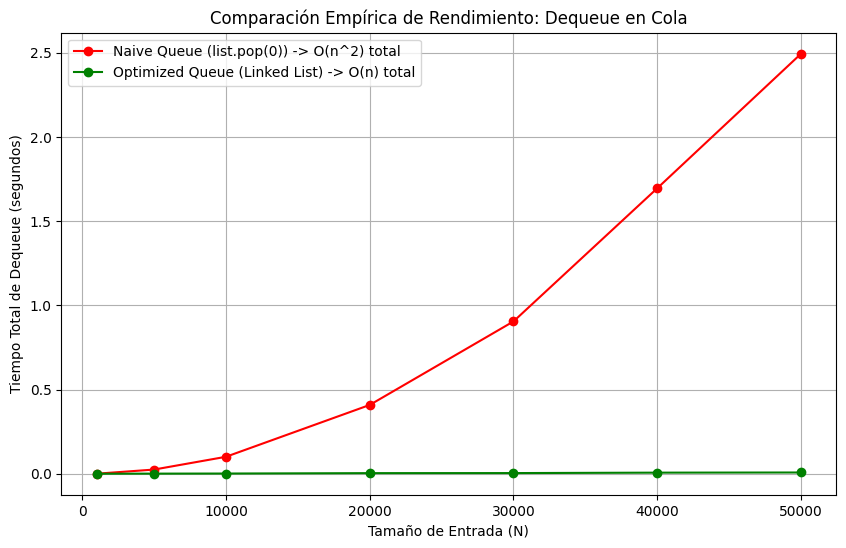

In [2]:
import time
import matplotlib.pyplot as plt

def run_benchmark():
    sizes = [1000, 5000, 10000, 20000, 30000, 40000, 50000]
    naive_times = []
    opt_times = []

    for n in sizes:
        # Benchmark Naive Queue
        nq = NaiveQueue()
        for i in range(n):
            nq.enqueue(i)
        
        start_time = time.perf_counter()
        while not nq.is_empty():
            nq.dequeue()
        naive_times.append(time.perf_counter() - start_time)

        # Benchmark Optimized Queue
        oq = OptimizedQueue()
        for i in range(n):
            oq.enqueue(i)
            
        start_time = time.perf_counter()
        while not oq.is_empty():
            oq.dequeue()
        opt_times.append(time.perf_counter() - start_time)

    # Graficar
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, naive_times, 'ro-', label='Naive Queue (list.pop(0)) -> O(n^2) total')
    plt.plot(sizes, opt_times, 'go-', label='Optimized Queue (Linked List) -> O(n) total')
    plt.xlabel('Tamaño de Entrada (N)')
    plt.ylabel('Tiempo Total de Dequeue (segundos)')
    plt.title('Comparación Empírica de Rendimiento: Dequeue en Cola')
    plt.legend()
    plt.grid(True)
    plt.show()

# Nota: Si estás ejecutando localmente este notebook, puedes descomentar la siguiente línea para ejecutar el benchmark.
run_benchmark()


## 4. Rincón del Co-pilot (IA en la Industria)

### Prompt para Probar con LLMs:
> *"Escribe una clase de Python que implemente una estructura de datos tipo Cola (Queue) utilizando Programación Orientada a Objetos. Debe tener métodos para encolar y desencolar elementos rápidamente."*

### Análisis Crítico de la Solución de la IA:
Cuando le pides a una Inteligencia Artificial Generativa que implemente una cola rápida en Python, a menudo comete los siguientes errores conceptuales o de diseño:

1. **Uso ingenuo de `list.pop(0)`:** La IA frecuentemente te dará una clase que usa una lista interna y hace `self.items.pop(0)`. En sus explicaciones te dirá alegremente: *"Esta función desencola el elemento en tiempo constante"*. **¡FALSO!** Como vimos en el benchmark, el costo oculto de reorganizar el arreglo dinámico en memoria de Python es $O(n)$ en tiempo de ejecución.
2. **Falta de soporte de Concurrencia:** En un sistema de producción real, una cola suele ser compartida entre múltiples hilos o procesos de trabajo (workers). Las implementaciones nativas o las sugeridas por la IA carecen de mecanismos de sincronización de bloqueos (`threading.Lock`), lo que provoca condiciones de carrera (race conditions) y corrupción de datos si no se diseñan adecuadamente.
3. **Uso de `collections.deque` sin explicar el porqué:** Si la IA te sugiere usar `collections.deque`, esto es correcto desde el punto de vista del rendimiento ($O(1)$ en extremos), pero no te explica que detrás se implementa una estructura de **lista doblemente enlazada por bloques**, lo que priva al estudiante del aprendizaje fundamental de los punteros y la gestión de memoria subyacente.


## 5. Actividades y Retos en Clase (Hands-on)

### Ejercicio 1 (Guiado): Encontrar y corregir el bug de la Pila MinStack

Una Pila con soporte para obtener el elemento mínimo en $O(1)$ es un clásico problema. La siguiente implementación tiene un bug en el método `pop` que causa que el valor mínimo deje de ser correcto tras algunas operaciones.
**Instrucciones:** Identifica el bug, descríbelo y corrígelo en la celda correspondiente para pasar las pruebas unitarias básicas.


In [ ]:
class MinStackBuggy:
    def __init__(self) -> None:
        self.stack: list[int] = []
        self.min_stack: list[int] = []

    def push(self, val: int) -> None:
        self.stack.append(val)
        if not self.min_stack or val <= self.min_stack[-1]:
            self.min_stack.append(val)

    def pop(self) -> None:
        # BUG: Esta implementación de pop tiene un problema grave
        if self.stack:
            val = self.stack.pop()
            # El bug está aquí: ¿Cuándo debemos remover del min_stack?
            if val == self.min_stack[-1]:
                self.min_stack.pop()

    def top(self) -> int:
        return self.stack[-1]

    def get_min(self) -> int:
        return self.min_stack[-1]

# --- TU SOLUCIÓN CORREGIDA ---
class MinStackCorrect:
    def __init__(self) -> None:
        self.stack: list[int] = []
        self.min_stack: list[int] = []

    def push(self, val: int) -> None:
        self.stack.append(val)
        if not self.min_stack or val <= self.min_stack[-1]:
            self.min_stack.append(val)

    def pop(self) -> None:
        if not self.stack:
            return
        val = self.stack.pop()
        if val == self.min_stack[-1]:
            self.min_stack.pop()

    def top(self) -> int:
        if not self.stack:
            raise IndexError("Pila vacía")
        return self.stack[-1]

    def get_min(self) -> int:
        if not self.min_stack:
            raise IndexError("Pila vacía")
        return self.min_stack[-1]

# Pruebas unitarias de verificación
try:
    ms = MinStackCorrect()
    ms.push(2)
    ms.push(0)
    ms.push(3)
    ms.push(0)
    
    assert ms.get_min() == 0
    ms.pop() # Saca el 0
    assert ms.get_min() == 0
    ms.pop() # Saca el 3
    assert ms.get_min() == 0
    ms.pop() # Saca el 0
    assert ms.get_min() == 2 # El mínimo ahora debe ser 2
    print("✓ ¡Pruebas superadas con éxito!")
except AssertionError:
    print("✗ Error: El valor mínimo de la pila no se actualizó correctamente.")


### Ejercicio 2 (Reto Autónomo): Implementación de un Deque con Lista Doblemente Enlazada (LeetCode Medium)

Un **Deque** (Double-Ended Queue) es una estructura de datos lineal que permite insertar y eliminar elementos eficientemente tanto por el frente como por el final.

**Reto:** Utiliza POO y tipado estático para implementar la clase `DoublyLinkedListDeque` de forma que todas las operaciones dadas (`insert_front`, `insert_rear`, `delete_front`, `delete_rear`, `get_front`, `get_rear`) se ejecuten en tiempo constante $O(1)$. No se permite utilizar listas dinámicas internas de Python.


In [ ]:
from typing import Optional, Any

class DLNode:
    def __init__(self, value: Any) -> None:
        self.value: Any = value
        self.next: Optional[DLNode] = None
        self.prev: Optional[DLNode] = None

class DoublyLinkedListDeque:
    def __init__(self) -> None:
        self.front: Optional[DLNode] = None
        self.rear: Optional[DLNode] = None
        self._size: int = 0

    def insert_front(self, value: Any) -> None:
        """Inserta un elemento al frente del deque: O(1)"""
        new_node = DLNode(value)
        if self.is_empty():
            self.front = new_node
            self.rear = new_node
        else:
            new_node.next = self.front
            self.front.prev = new_node
            self.front = new_node
        self._size += 1

    def insert_rear(self, value: Any) -> None:
        """Inserta un elemento al final del deque: O(1)"""
        new_node = DLNode(value)
        if self.is_empty():
            self.front = new_node
            self.rear = new_node
        else:
            new_node.prev = self.rear
            self.rear.next = new_node
            self.rear = new_node
        self._size += 1

    def delete_front(self) -> Any:
        """Elimina y retorna el elemento al frente del deque: O(1)"""
        if self.is_empty():
            raise IndexError("delete de un deque vacío")
        
        value = self.front.value
        self.front = self.front.next
        if self.front is None:
            self.rear = None
        else:
            self.front.prev = None
        self._size -= 1
        return value

    def delete_rear(self) -> Any:
        """Elimina y retorna el elemento al final del deque: O(1)"""
        if self.is_empty():
            raise IndexError("delete de un deque vacío")
        
        value = self.rear.value
        self.rear = self.rear.prev
        if self.rear is None:
            self.front = None
        else:
            self.rear.next = None
        self._size -= 1
        return value

    def get_front(self) -> Any:
        if self.is_empty():
            raise IndexError("deque vacío")
        return self.front.value

    def get_rear(self) -> Any:
        if self.is_empty():
            raise IndexError("deque vacío")
        return self.rear.value

    def is_empty(self) -> bool:
        return self._size == 0

    def size(self) -> int:
        return self._size

# Validación de tu reto:
try:
    deque = DoublyLinkedListDeque()
    deque.insert_front(10)
    deque.insert_rear(20)
    deque.insert_front(5)
    
    assert deque.get_front() == 5
    assert deque.get_rear() == 20
    assert deque.size() == 3
    
    assert deque.delete_front() == 5
    assert deque.delete_rear() == 20
    assert deque.size() == 1
    
    print("✓ ¡Reto autónomo resuelto y validado correctamente!")
except Exception as e:
    print(f"✗ Hubo un error en tu implementación: {e}")


### Pregunta de Discusión en Grupo:

*¿Por qué la estructura de lista integrada de Python (`list`) está implementada internamente como un arreglo dinámico de punteros continuos en lugar de una lista doblemente enlazada? Analiza la localidad de referencia en caché de CPU y los costes de almacenamiento extra para punteros en sistemas de 64 bits.*
